# **Desarrollo de Actividad 4 - Curso de Análisis estadístico para modelos no supervisados**


**Proyecto:** Análisis factorial a series temporales de contaminantes atmosféricos y calidad del aire a nivel global

**Presentado por:**

•	Adriana Patricia Rodriguez Toloza

**Fecha:** 05 de junio de 2026

## **Selección del conjunto de datos y comprensión del contexto:**

Para el desarrollo del presente proyecto se seleccionó como base de datos el dataset Global Urban Air Quality & Pollution Time-Series, la cual recolecta información detallada de variables de contaminación atmosferica de 50 de las ciudades más pobladas e industrializadas del mundo de un año.

Este conjunto de datos inlcuye indicadores ambientales que permitirán analizar la calidad del aire, identificar patrones de contaminación, y explorar relaciones mediante técnicas de análisis multivariado como el análisis factorial.

La base de datos contiene más de 254000 registros y 13 variables de medición como:
* **Timestamp:** Fecha y hora local de la medición
* **City:** Ciudad
* **Latitude:** Latitud geoespacial del centro de la ciudad
* **Longitude:** Longitud geoespacial del centro de la ciudad
* **PM10 μg/m3:** Concentración de material particulado grueso de hasta 10 microgramos como polvo y polen
* **PM2.5 μg/m3:** Concentración de material particulado (fino) de hasta 2.5 microgramos como los procedentes de los gases de escape de vehículos, muy peligrosos para la salud respiratoria.
* **Carbon Monoxide μg/m3:** Concentración de niveles de CO.
* **Dioxide Nitrogen μg/m3:** Concentración de NO2 altamente relacionado con la congestion del tráfico pesado.
* **Ozone μg/m3:** Concentración de nivees de ozono en el suelo.
* **Dust μg/m3:** Concentración de ceniza atmosférica.
* **UV Index:** Indice de exposición a la radiación solar.
* **European AQI:** Indice general estandarizado de  calidad del aire (entra más alto peor)
* **Hazardous Event:** Variable binaria. Determina si la calidad del aire es categorizado como peligroso o no.
  * 1 Peligroso. Ocurre si el AQI > 100
  * 0 No peligroso



## **Objetivo:**
El objetivo del proyecto es determinar la existencia de factores latentes que expliquen la variabilidad y correlación entre las variables de contaminación atmosférica utilizando técnicas de análisis factorial para reducir la dimensionalidad y facilitar la interpretación de patrones.  


## **Paso 1: Cargue de información:**

### ***1.1 Instalar e importar librerias:***

In [ ]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=718b43a1496bb3ae47a11f4dcadf60bee8317fc02bd4f555bd25f8b9acc887f0
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [ ]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 3.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

### ***1.2 Conexión con drive:***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### ***1.3 Lectura del dataset:***

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/No supervisados/Actividad 4/global_urban_smog_pm25_hourly.csv")

In [ ]:
df.head()

,Timestamp,City,Latitude,Longitude,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index,European_AQI,Hazardous_Event
0,2025-05-22T00:00,Lahore,31.5204,74.3587,186.7,74.3,926.0,22.9,94.0,197.0,0.0,76,0
1,2025-05-22T01:00,Lahore,31.5204,74.3587,286.8,96.4,736.0,18.1,103.0,356.0,0.0,77,0
2,2025-05-22T02:00,Lahore,31.5204,74.3587,380.0,122.0,599.0,14.1,110.0,506.0,0.0,78,0
3,2025-05-22T03:00,Lahore,31.5204,74.3587,486.2,149.9,548.0,11.7,114.0,640.0,0.0,80,0
4,2025-05-22T04:00,Lahore,31.5204,74.3587,581.1,172.8,550.0,10.1,118.0,765.0,0.0,85,0


## **Paso 2: Exploración inicial de los datos:**

### ***2.1 Exploración de variables:***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254736 entries, 0 to 254735
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Timestamp               254736 non-null  object 
 1   City                    254736 non-null  object 
 2   Latitude                254736 non-null  float64
 3   Longitude               254736 non-null  float64
 4   PM10_ug_m3              254710 non-null  float64
 5   PM2_5_ug_m3             254736 non-null  float64
 6   Carbon_Monoxide_ug_m3   254736 non-null  float64
 7   Nitrogen_Dioxide_ug_m3  254736 non-null  float64
 8   Ozone_ug_m3             254736 non-null  float64
 9   Dust_ug_m3              254736 non-null  float64
 10  UV_Index                254736 non-null  float64
 11  European_AQI            254736 non-null  int64  
 12  Hazardous_Event         254736 non-null  int64  
dtypes: float64(9), int64(2), object(2)
memory usage: 25.3+ MB


Mediante el método info es posible identificar que el dataset contiene 254736 registros y 13 columnas. Estas variables se carectizan de la siguiente forma:

* Variables cualitativas (1):city

* Variables cuantitativas:
  * Discretas (2): European AQI, Hazardous event
  * Continuas (9): latitude, longitude, PM10, PM2.5, Carbon monoxide, Dioxide Nitrorgen, Ozone, Dust, UV Index.
  * Cuantitativa Temporal (1):  Timestamp

  Así mismo, es posible identificar que la variable PM10 contiene cerca de 26 registros nulos los cuales se debe realizar tratamiento antes de crear el modelo.

### ***2.2 Medidas de localización y dispersión:***

In [ ]:
df.describe().round(2)

,Latitude,Longitude,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index,European_AQI,Hazardous_Event
count,254736.00,254736.00,254710.00,254736.00,254736.00,254736.00,254736.00,254736.00,254736.00,254736.00,254736.00
mean,22.19,25.64,87.31,36.65,698.00,33.69,60.94,99.99,1.39,75.84,0.13
std,23.05,74.68,274.77,40.99,991.32,27.58,47.50,525.50,2.42,101.03,0.34
min,-34.60,-118.24,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.00,0.00
25%,13.76,-46.63,15.70,12.90,232.00,12.80,27.00,0.00,0.00,34.00,0.00
50%,28.61,37.62,30.60,22.90,376.00,25.10,53.00,1.00,0.00,61.00,0.00
75%,37.57,77.21,60.50,44.50,710.00,47.70,83.00,13.00,1.80,78.00,0.00
max,55.76,139.69,3270.80,624.00,19081.00,309.20,523.00,10166.00,15.85,1227.00,1.00


In [ ]:
df.columns

Index(['Timestamp', 'City', 'Latitude', 'Longitude', 'PM10_ug_m3',
       'PM2_5_ug_m3', 'Carbon_Monoxide_ug_m3', 'Nitrogen_Dioxide_ug_m3',
       'Ozone_ug_m3', 'Dust_ug_m3', 'UV_Index', 'European_AQI',
       'Hazardous_Event'],
      dtype='object')

In [ ]:
variables = ['PM10_ug_m3','PM2_5_ug_m3', 'Carbon_Monoxide_ug_m3', 'Nitrogen_Dioxide_ug_m3',
       'Ozone_ug_m3', 'Dust_ug_m3', 'UV_Index', 'European_AQI','Hazardous_Event']

#Cálculo del coeficiente de variación
coeficiente_variacion= ((df[variables].std()/df[variables].mean())*100).round(2)
coeficiente_variacion

,0
PM10_ug_m3,314.72
PM2_5_ug_m3,111.86
Carbon_Monoxide_ug_m3,142.02
Nitrogen_Dioxide_ug_m3,81.86
Ozone_ug_m3,77.93
Dust_ug_m3,525.57
UV_Index,174.49
European_AQI,133.21
Hazardous_Event,256.27


Mediante el método .decribe() es posible evidenciar:
1. Las variables se encuentran en diferentes escalas y son de diferente tamaño, por lo cual antes de crear el modelo es importante escalarlas.
2. Se identifica que las variables PM10, PM2.5, Carbon monoxide, Nitrogen Dioxide, Ozone, Dust y European AQi presentan saltos entre cuartiles de manera significativa, mostrando posibles valores atipicos que muestran altas concentraciones.
3. No hay coincidencia entre la media y la mediana de cada variable, indicando asimetria (sesgo)en las variables. En las  variables de interés ambiental la media > mediana, por lo cual, existe un sesgo positivo (cola a la derecha) en las variables posiblemente afectado por la presencia de valores atipicos.
4. La amplitud del rango (min y max) muestra valores extremadamente alto a tratar.
5. Considerando el coeficiente de varición es posible identificar que son >30%, por lo cual la dispersión en las variables es alta y extremadamente alta.  


### ***2.3 Medidas de forma:***

In [ ]:
#Asimetria
asimetria = df[variables].skew().round(2)

#Curtosis
curtosis =df[variables].kurtosis().round(2)


forma = pd.DataFrame({"Asimetria": asimetria,
                      "Curtosis:":curtosis})
forma


,Asimetria,Curtosis:
PM10_ug_m3,7.26,58.79
PM2_5_ug_m3,3.16,15.11
Carbon_Monoxide_ug_m3,4.68,32.04
Nitrogen_Dioxide_ug_m3,1.39,2.30
Ozone_ug_m3,1.32,2.79
Dust_ug_m3,7.77,69.33
UV_Index,2.01,3.48
European_AQI,5.78,39.73
Hazardous_Event,2.17,2.72


**Interpretación de medidas de forma:**
  * **Asimetria:**
    * Asimetria = 0 Simetrica
    * Asimetria > 0 Positiva, cola a la derecha, pocos valores muy grandes.
    * Asimetria < 0 Negativa, cola a la izquieda, pocos datos con valores muy pequeños

  * **Curtosis:**
    * Curtosis > 0: Leptocúrtica (punta alta y delgada)
    * Curtosis = 0: Mesocúrtica (Distribución en campana - normal)
    * Curtosis < 0: Platicúrtica (puntal alta y chata

Mediante el cálculo de las medidas de forma, las metricas confirmar la asimetria positiva (sesgo - cola a la derecha) y una curtosis por lo tanto leptocurtica.

Para realizar el modelamiento por análisis factorial es importante tratar este sesgo ya que se encuentra basado en correlaciones  de  Pearson que asumen una distribución normal.

### ***2.4 Histogramas:***

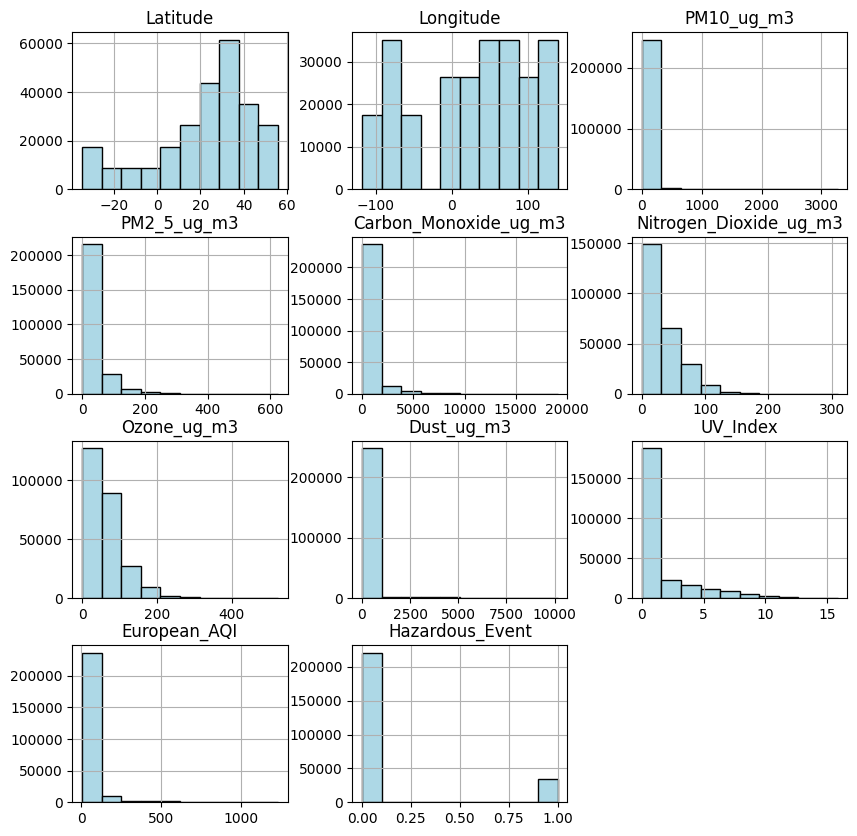

In [ ]:
df.hist(figsize=(10,10),edgecolor="black",color="lightblue")
plt.show()

Con los histogramas es posibles visualizar que los indicadores ambientales de estudio presentan sesgo y asimetria positiva (cola a la derecha).

### ***2.5 Boxplot:***

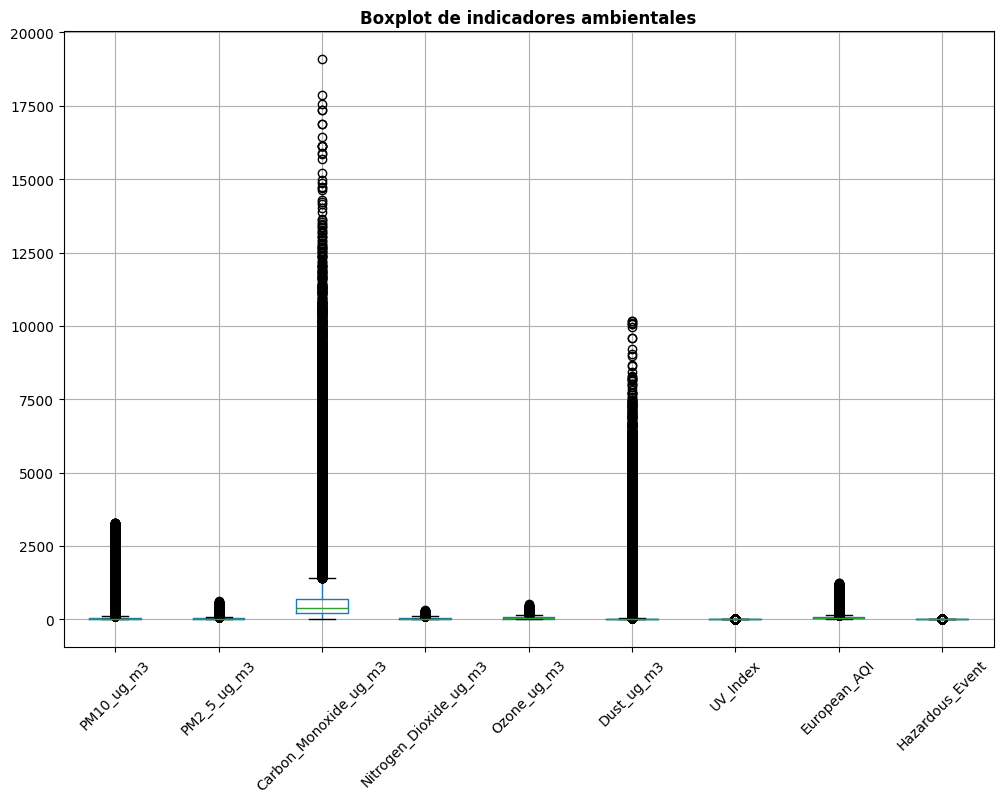

In [ ]:
df[variables].boxplot(figsize=(12,8),rot=45)
plt.title("Boxplot de indicadores ambientales", fontweight="bold")
plt.show()

Mediante el boxplot se observa cómo las variables presentan escalas diferentes y valores atipicos significativos en las variables PM10, Carbon Monoxide y Dust. Estudiemos un poco los casos:



In [ ]:
Q99= df["Carbon_Monoxide_ug_m3"].quantile(0.99)

filtro = df[(df["Carbon_Monoxide_ug_m3"]>Q99)]
filtro

,Timestamp,City,Latitude,Longitude,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index,European_AQI,Hazardous_Event
1390,2025-07-18T22:00,Lahore,31.5204,74.3587,115.3,105.9,5397.0,117.5,28.0,19.0,0.0,86,0
1391,2025-07-18T23:00,Lahore,31.5204,74.3587,125.7,115.9,5660.0,118.1,22.0,19.0,0.0,88,0
1392,2025-07-19T00:00,Lahore,31.5204,74.3587,131.3,121.5,5637.0,117.3,17.0,19.0,0.0,90,0
1393,2025-07-19T01:00,Lahore,31.5204,74.3587,135.5,125.7,5395.0,114.1,14.0,19.0,0.0,92,0
2564,2025-09-05T20:00,Lahore,31.5204,74.3587,64.3,63.8,5421.0,138.1,34.0,1.0,0.0,66,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
228625,2025-06-01T01:00,Johannesburg,-26.2041,28.0473,174.6,173.7,5919.0,74.7,3.0,0.0,0.0,87,0
228909,2025-06-12T21:00,Johannesburg,-26.2041,28.0473,93.8,92.9,5269.0,72.5,2.0,0.0,0.0,114,1
228910,2025-06-12T22:00,Johannesburg,-26.2041,28.0473,95.7,94.8,5760.0,66.1,4.0,0.0,0.0,112,1
228911,2025-06-12T23:00,Johannesburg,-26.2041,28.0473,90.1,89.4,5607.0,60.0,6.0,0.0,0.0,109,1


In [ ]:
Q99= df['Dust_ug_m3'].quantile(0.99)

filtro = df[(df['Dust_ug_m3']>Q99)]
filtro

,Timestamp,City,Latitude,Longitude,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index,European_AQI,Hazardous_Event
210833,2025-05-22T17:00,Riyadh,24.7136,46.6753,1478.9,119.0,194.0,14.9,87.0,3259.0,0.45,218,1
210834,2025-05-22T18:00,Riyadh,24.7136,46.6753,1668.9,139.7,210.0,19.1,78.0,3258.0,0.05,235,1
210857,2025-05-23T17:00,Riyadh,24.7136,46.6753,1572.1,136.0,180.0,15.3,103.0,3405.0,0.40,357,1
210858,2025-05-23T18:00,Riyadh,24.7136,46.6753,1810.5,161.1,201.0,19.7,96.0,3535.0,0.05,359,1
210889,2025-05-25T01:00,Riyadh,24.7136,46.6753,1929.7,187.7,178.0,16.6,75.0,3205.0,0.00,382,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
219595,2026-05-22T19:00,Riyadh,24.7136,46.6753,2086.2,259.8,160.0,24.5,72.0,3547.0,0.00,894,1
219596,2026-05-22T20:00,Riyadh,24.7136,46.6753,2175.6,278.5,157.0,23.8,76.0,3914.0,0.00,913,1
219597,2026-05-22T21:00,Riyadh,24.7136,46.6753,2346.9,307.3,153.0,22.6,82.0,4196.0,0.00,930,1
219598,2026-05-22T22:00,Riyadh,24.7136,46.6753,2518.3,339.0,149.0,20.6,89.0,4401.0,0.00,943,1


In [ ]:
Q99= df['PM10_ug_m3'].quantile(0.99)

filtro = df[(df['PM10_ug_m3']>Q99)]
filtro

,Timestamp,City,Latitude,Longitude,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index,European_AQI,Hazardous_Event
210858,2025-05-23T18:00,Riyadh,24.7136,46.6753,1810.5,161.1,201.0,19.7,96.0,3535.0,0.05,359,1
210889,2025-05-25T01:00,Riyadh,24.7136,46.6753,1929.7,187.7,178.0,16.6,75.0,3205.0,0.00,382,1
210890,2025-05-25T02:00,Riyadh,24.7136,46.6753,2205.4,217.0,158.0,12.9,81.0,3786.0,0.00,407,1
210912,2025-05-26T00:00,Riyadh,24.7136,46.6753,2019.1,194.2,211.0,26.3,69.0,3795.0,0.00,472,1
210913,2025-05-26T01:00,Riyadh,24.7136,46.6753,2540.6,269.2,201.0,19.4,81.0,3806.0,0.00,481,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
219595,2026-05-22T19:00,Riyadh,24.7136,46.6753,2086.2,259.8,160.0,24.5,72.0,3547.0,0.00,894,1
219596,2026-05-22T20:00,Riyadh,24.7136,46.6753,2175.6,278.5,157.0,23.8,76.0,3914.0,0.00,913,1
219597,2026-05-22T21:00,Riyadh,24.7136,46.6753,2346.9,307.3,153.0,22.6,82.0,4196.0,0.00,930,1
219598,2026-05-22T22:00,Riyadh,24.7136,46.6753,2518.3,339.0,149.0,20.6,89.0,4401.0,0.00,943,1


El boxplot y la extracción de los datos pueden estar mostrando niveles de concentración muy significativos posiblemente derivados de eventos climáticos, incendios o un tráfico intenso caractetrizado por combustión incompleta. En esta caso no se pretende desmeritar la información que puede aportar por lo que se busca es aplicar técnicas para reducir el impacto en el modelo de los valores atipicos.

Examinemos las variables con escalas pequeñas:

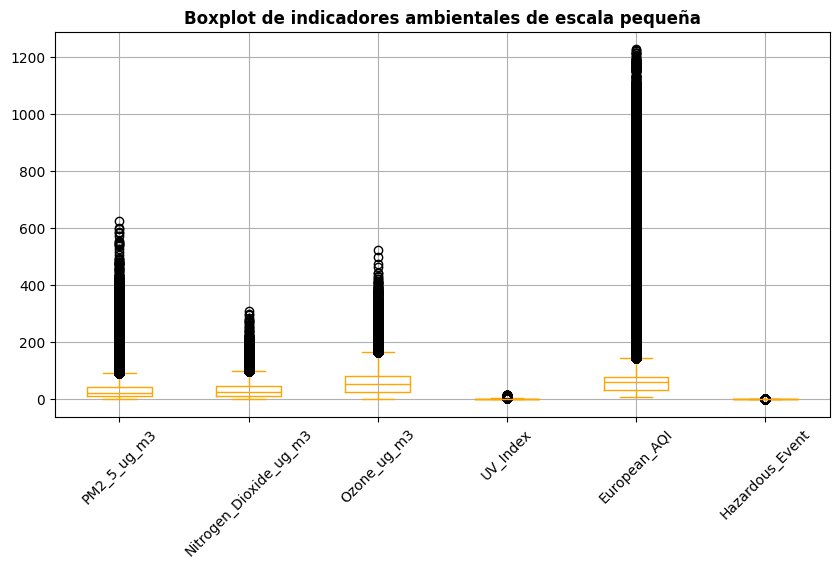

In [ ]:
#Boxplot de indicadores con escala mas pequeña
variables_esc_baja=[ 'PM2_5_ug_m3', 'Nitrogen_Dioxide_ug_m3',
       'Ozone_ug_m3',  'UV_Index', 'European_AQI',
       'Hazardous_Event']

df[variables_esc_baja].boxplot(figsize=(10,5),rot=45,color="orange")
plt.title("Boxplot de indicadores ambientales de escala pequeña", fontweight="bold")
plt.show()

Se identifica que las variables con escalas más pequeñas también presentan una cantidad significativa de valores considerados atipicos.

### ***2.3 Identificación de registros duplicados***

In [ ]:
df.duplicated().sum()

np.int64(0)

La base de datos no presenta registros duplicados.

### ***2.4 Identificación de registros con valores nulos:***

In [ ]:
df.isnull().sum() #Conteo de valores nulos

,0
Timestamp,0
City,0
Latitude,0
Longitude,0
PM10_ug_m3,26
PM2_5_ug_m3,0
Carbon_Monoxide_ug_m3,0
Nitrogen_Dioxide_ug_m3,0
Ozone_ug_m3,0
Dust_ug_m3,0


La base de datos presenta 26 registros nulos en la variable PM10.


In [ ]:
(((df.isnull().sum())/(df.shape[0]))*100).round(3) #Porcentaje de valores  nulos

,0
Timestamp,0.00
City,0.00
Latitude,0.00
Longitude,0.00
PM10_ug_m3,0.01
PM2_5_ug_m3,0.00
Carbon_Monoxide_ug_m3,0.00
Nitrogen_Dioxide_ug_m3,0.00
Ozone_ug_m3,0.00
Dust_ug_m3,0.00


El porcentaje de valores nulos es de 0.01%, el cual es menor al 5% por lo cual es factible eliminarlos si afectar de manera significativa el dataset.

In [ ]:
df=df.dropna()

In [ ]:
df.shape

(254710, 13)

## **Paso 3: Escalamiento y correlación entre variables:**

### ***3.1 Selección de variables cuantitativas:***

In [ ]:
df.columns

Index(['Timestamp', 'City', 'Latitude', 'Longitude', 'PM10_ug_m3',
       'PM2_5_ug_m3', 'Carbon_Monoxide_ug_m3', 'Nitrogen_Dioxide_ug_m3',
       'Ozone_ug_m3', 'Dust_ug_m3', 'UV_Index', 'European_AQI',
       'Hazardous_Event'],
      dtype='object')

La variable 'European_AQI' representte el indice estandarizado de calidad del aire y está calculado sobre las demás variables.  Con el fin de no generar redundancia y correlaciones extremadamente altas, se decide no incluir este indicador.

In [ ]:
variables=['PM10_ug_m3', 'PM2_5_ug_m3', 'Carbon_Monoxide_ug_m3', 'Nitrogen_Dioxide_ug_m3',
       'Ozone_ug_m3', 'Dust_ug_m3', 'UV_Index']


### ***3.2 Transformación:***

Dado que la asimetria de los indicadores ambientales fueron > 1, resulta estrategico aplicar como técnica de transformación el logaritmo para reducir el impacto de los valores atipicos. Esta transformación se realizará sobre todas los indicadores ambientales con base en que todos presentan estos outliers.

In [ ]:
df_log = np.log1p(df[variables])#Se aplica log(1+x)

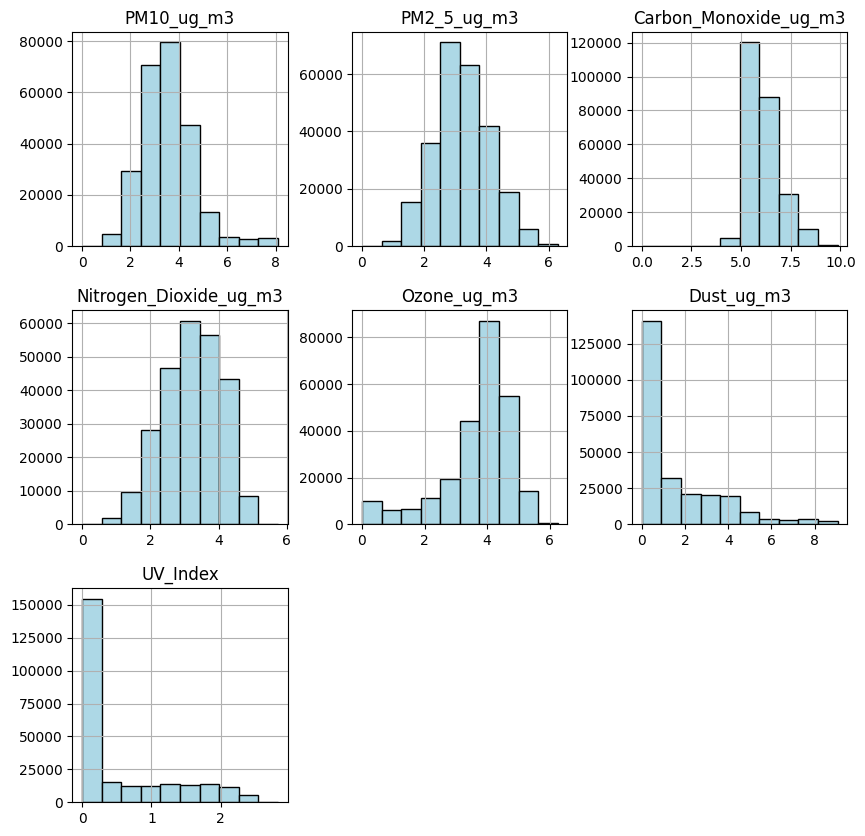

In [ ]:
df_log.hist(figsize=(10,10),edgecolor="black",color="lightblue")
plt.show()

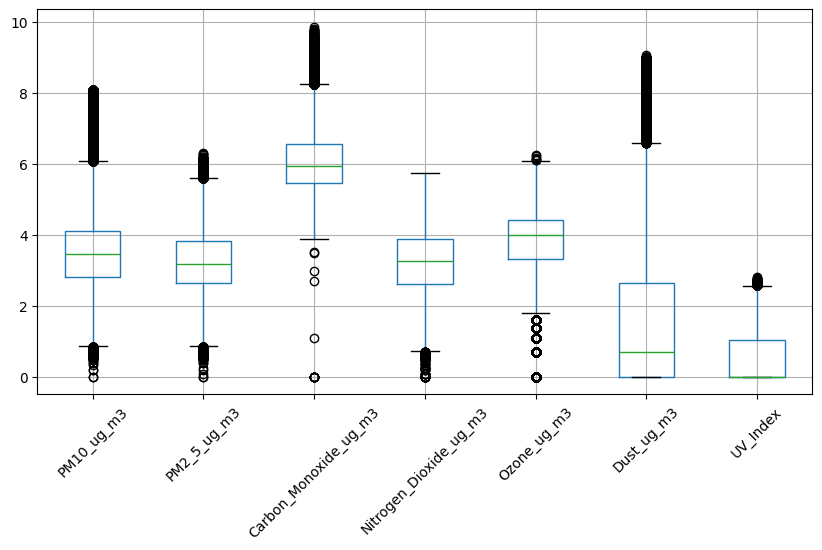

In [ ]:
df_log.boxplot(figsize=(10,5),rot=45)
plt.show()

Con la aplicación del logaritmo se observa una reducción de la asimetria y reducción del impacto de los valores extremos. Sin embargo las exalas continuan siendo diferentes y por lo cual aplicar tecnica de estandarización.

### ***3.3. Estandarización robusta:***

Se uttilizó la técnica de  estandarización robusta para escalar los datos sin verse afectado por los valores extremos.

In [ ]:
scaler= RobustScaler()
df_scaled=pd.DataFrame(scaler.fit_transform(df_log),
                       columns=variables)

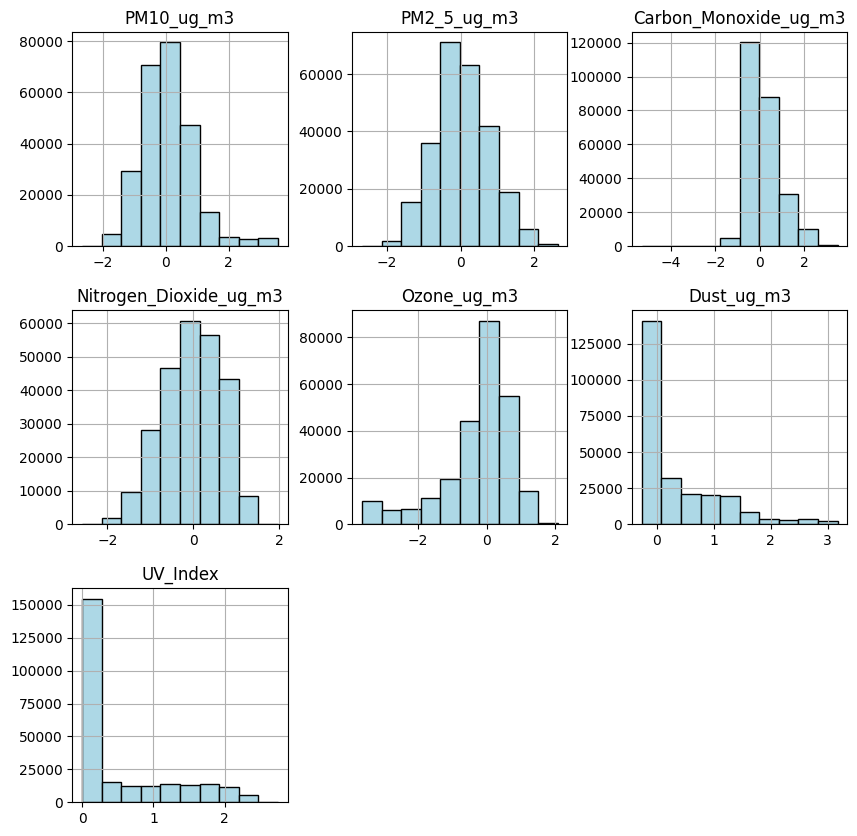

In [ ]:
df_scaled.hist(figsize=(10,10),edgecolor="black",color="lightblue")
plt.show()

### ***3.4 Correlación entre variables:***

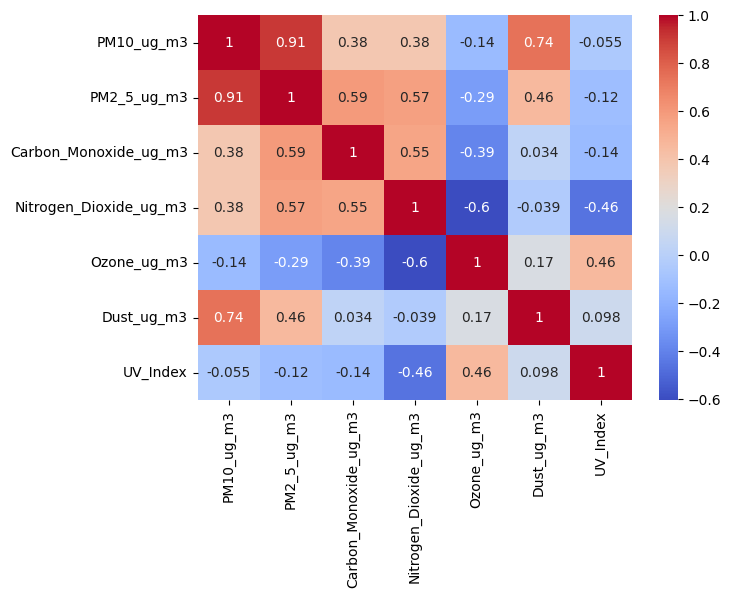

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(df_scaled.corr(),cmap="coolwarm", annot=True)
plt.show()

Se realiza mapa de calor de correlaciones de Pearson entre variables, identificando correlaciones leves, moderadas y altas.

Se identifica una alta colinealidad entre PM10 y PM2.5. Sin embargo, debido a la importancia clinica del PM2.5 se decide dejarla.

## **Paso 4: Aplicación de pruebas preliminares:**

### ***4.1 Evaluación KMO (Kaiser - Meyer - Olkin):***


La prueba de KMO es una prueba estadística que permite determinar si los datos son adecuados para un análisis factorial.
Mediante KMO es posible determinar si las correlaciones son suficientes.

KMO varia entre 0 a 1 en donde entre más cercanos se encuentra el valor a 1 indica que las variables están correlacionadas y los datos son adecuados para el análisis  factorial. Si el valor es cercano a cero indica que las variables no están correlacionadas y es posible que no haya un factor común que influya.
Los parámetros de interpretación son los siguientes explicitamente:

*   .> 0.9 Excelente
*   0.8 a 0.89 Muy buena
*   0.70 a 0.79 Buena
*   0.60 a 0.69 Aceptable
*   < 0.50 No recomendable




In [ ]:
kmo_all, kmo_model =calculate_kmo(df_scaled)
print("KMO global:", round(kmo_model,3))

KMO global: 0.585


La evaluación KMO muestra significancia un poco baja, por lo cual, se decide verificar el KMO por variable para revisar si existe alguna o algunas significativamente baja.

In [ ]:
kmo_variables = pd.DataFrame({
    "Variable": df_scaled.columns,
    "KMO": kmo_all})

kmo_variables

,Variable,KMO
0,PM10_ug_m3,0.498378
1,PM2_5_ug_m3,0.535342
2,Carbon_Monoxide_ug_m3,0.683100
3,Nitrogen_Dioxide_ug_m3,0.819642
4,Ozone_ug_m3,0.776099
5,Dust_ug_m3,0.398863
6,UV_Index,0.719587


Se evidencia que el kmo de la variable Dust es muy baja, y de manera baja y moderada de PM10 y PM2.5. Por lo cual se decide eliminar la variable Dust para ver como cambia.

In [ ]:
df_scaled =df_scaled.drop(columns=["Dust_ug_m3"])

In [ ]:
kmo_all, kmo_model =calculate_kmo(df_scaled)
kmo_variables = pd.DataFrame({
    "Variable": df_scaled.columns,
    "KMO": kmo_all})

kmo_variables

,Variable,KMO
0,PM10_ug_m3,0.526902
1,PM2_5_ug_m3,0.570679
2,Carbon_Monoxide_ug_m3,0.706279
3,Nitrogen_Dioxide_ug_m3,0.760758
4,Ozone_ug_m3,0.789281
5,UV_Index,0.708102


In [ ]:
print("KMO global:", round(kmo_model,3))
kmo = pd.DataFrame({kmo_model},index=["KMO Global"])
kmo

KMO global: 0.647


,0
KMO Global,0.646845


La pruebade KMO muestra que la estructura correlacional es aceptable ahora.

### ***4.2 Prueba de esfericidad de Bartlett:***




La prueba de Barlett evalúa si las variables están significativamente correlacionadas.

Esta prueba coloca bajo hipotesis nula de  que las variables son independientes, es decir, no están correlacionadas.


> H0: Matriz de correlaciones = Matriz identidad , es decir no están correlacionadas

> Ha: Matriz de correlaciones ≠ Matriz identidad , existe un grado suficiente de correlación


Si p-valor < 0.05 se rechaza la hipótesis nula.
Si p-valor > 0.05 Se acepta la hipotesis nula

In [ ]:
chi_square,p_value = calculate_bartlett_sphericity(df_scaled)
print("Chi cuadradro:", chi_square)
print("p-value:",p_value)

if p_value <0.05:
  print("Conclusión: Se rechaza la hipotesis nula -> las variables están correlacionadas y se puede  continuar con el análisis")
else:
  print("Conclusión: Se acepta la hipotesis nula -> las variables no están correlacionadas por lo que no es adeacuado realizar análisis factorial")

Chi cuadradro: 969984.9827757837
p-value: 0.0
Conclusión: Se rechaza la hipotesis nula -> las variables están correlacionadas y se puede  continuar con el análisis


In [ ]:
bartlett = pd.DataFrame(p_value,index=["p-value:"],columns=["Bartlett test:"] )
bartlett

,Bartlett test:
p-value:,0.0


De acuerdo a la prueba de Bartlett las variables están correlacionadas y se puede continuar con el análsiis.

## **Paso 5: Determinación del número de factores:**

Dentro del análsis factorial lo que se busca es poder identificar factores ocultos (también llamadas variables latentes) que explican la relación entre las variables analizadas. General,ente, existe correlación entre las variables debido a que están relacionadas a un fenómeno no observado directamente.

El análisis factorial es por tanto una técnica multivariada que permite identificar estos factores o variables latentes que explican la correlación entre las variables y permite agruparlas caracterizandolas por este factor o caracteristica común.

Para realizar el análisis es importante determinar el número de factores, para lo cual, se utilizan métodos de extrracción factorial que son los procedimientos matemáticos del análsis factorial para encontrar los factores latentes usando la varianza común.

### ***5.1 Obtención de factores latentes y varianza explicada por cada factor (eigenvalues) sin rotación:***


In [ ]:
modelo_af = FactorAnalyzer(rotation=None)
modelo_af.fit(df_scaled)
eigenvalues,vectors = modelo_af.get_eigenvalues() #Obtención de eigenvalores y  eigenvectores

tabla =pd.DataFrame({"Factor:": range(1,len(eigenvalues)+1),
                     "Eigenvalue:":eigenvalues})
tabla

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor:,Eigenvalue:
0,1,3.097574
1,2,1.405199
2,3,0.680345
3,4,0.449155
4,5,0.314728
5,6,0.053000


### ***5.2 Determinación del número de factores por regla de Kaiser y Scree Plot:***

La regla de Kaiser define como criterio retener aquellos factores cuyos valores propios sean mayores.
Un valor propio de 1 significa que el factor contiene más información que una sola variable.

In [ ]:
kaiser = eigenvalues[eigenvalues>1]
print("Número de factores retenidos por regla de kaiser:", len(kaiser))
print(kaiser)

Número de factores retenidos por regla de kaiser: 2
[3.0975738  1.40519884]


Se puede utilizar un scree Plot para visualizar la regla de kaiser y compararlo con el método de determinación con el codo.

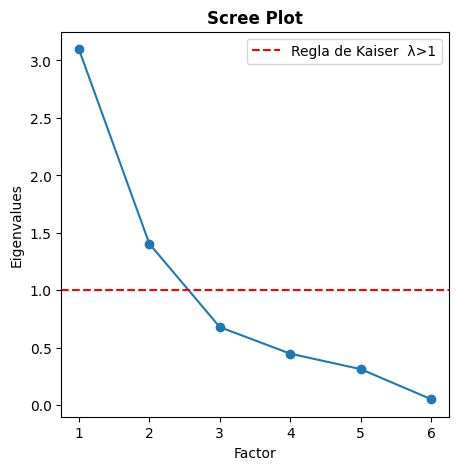

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(tabla["Factor:"], eigenvalues,marker="o")
plt.axhline(y=1,color="r",linestyle="--",label="Regla de Kaiser  λ>1")
plt.title("Scree Plot", fontweight="bold", fontsize=12)
plt.xlabel("Factor")
plt.ylabel("Eigenvalues")
plt.legend()
plt.show()

El método del codo recomendaria utilizar 3 factores y la regla de Kaiser 2.


 Para lo cual es recomendable ver revisar la varianza acumulada de cada factor.

### ***5.3 Corroboración de la varianza acumulada por el número de factores:***

In [ ]:
prop_varianza=eigenvalues/np.sum(eigenvalues) #Proporción de varianza explicada
varianza_acum=np.cumsum(prop_varianza) #Varianza acumulada



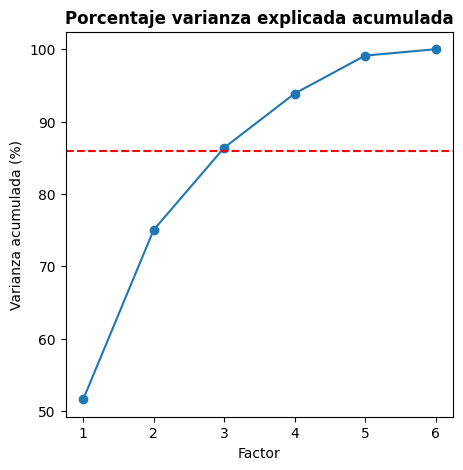

In [ ]:
factores= np.arange(1,len(eigenvalues)+1)

plt.figure(figsize=(5,5))
plt.plot(factores, varianza_acum*100,marker="o")
#plt.axhline( y=0.50,color="r",linestyle="--")
plt.title("Porcentaje varianza explicada acumulada",fontweight="bold")
plt.axhline(y=86, color="r",linestyle="--")
plt.xlabel("Factor")
plt.ylabel("Varianza acumulada (%)")
plt.show()

## **Paso 6: Análisis factorial:**


### ***6.1 Extracción factorial sin rotación:***


In [ ]:
modelo_none = FactorAnalyzer(n_factors=3, rotation=None)

modelo_none.fit(df_scaled)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(rotation=None, rotation_kwargs={})

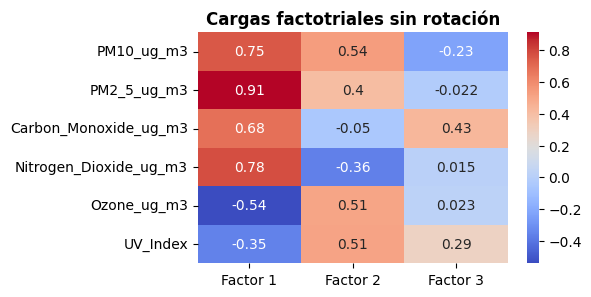

In [ ]:
#Cargas factoriales modelo sin rotación
loadings_none =pd.DataFrame(modelo_none.loadings_,
                       index=df_scaled.columns,
                       columns=["Factor 1","Factor 2",  "Factor 3"])
plt.figure(figsize=(5,3))
sns.heatmap(loadings_none,cmap="coolwarm",annot=True)
plt.title("Cargas factotriales sin rotación", fontweight="bold")
plt.show()


* Factor 1: Caracterizado por la concentració de PM10, PM2.5, CO y NO2
* Factor 2: caracterizada también por PM10 y PM2.5 y de manera complementaria por el Ozono y el indice de rayos UV
* Factor 3: Caracterizado principalmente por el CO de manera moderada.

Por el método sin rotación se evidencia cargas cruzadas (PM10, PM2.5 y CO).

### ***6.2 Extracción factorial ortogonal con varimax:***


La rotación varimax permite maximizar las cargas fuertes y minimizar las débiles, con el fin de hacer más interpretables los factores.
Supone que la correlación entre factores es cero.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


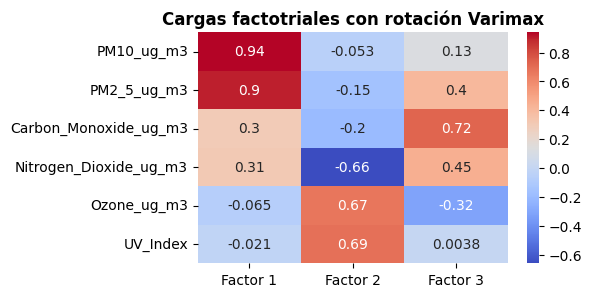

In [ ]:
modelo_varimax = FactorAnalyzer(n_factors=3, rotation="varimax")

modelo_varimax.fit(df_scaled)


loadings_varimax=pd.DataFrame(modelo_varimax.loadings_,
                              index=df_scaled.columns,
                              columns=["Factor 1","Factor 2",  "Factor 3"])

plt.figure(figsize=(5,3))
sns.heatmap(loadings_varimax,cmap="coolwarm",annot=True)
plt.title("Cargas factotriales con rotación Varimax", fontweight="bold")
plt.show()

Se utilizó tambien la rotación ortogonal varimax para visualizar como cambian las cargas, permitiendo interpretar mejor los factores.

* Factor 1: Caracterizado por la concentración de PM10 y PM2.5.
* Factor 2: Caracterizado por cargas como  O3, y el indice de rayos UV y en dirección opuesta el NO2.
* Factor 3: caracterizado por las cargas de CO, NO2, PM.2.5

### ***6.3 Extracción factorial oblicua Promax:***


Esta rotación asume que las correlaciones entre variables sea diferente de cero. Busca mejorar las comunalidades.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


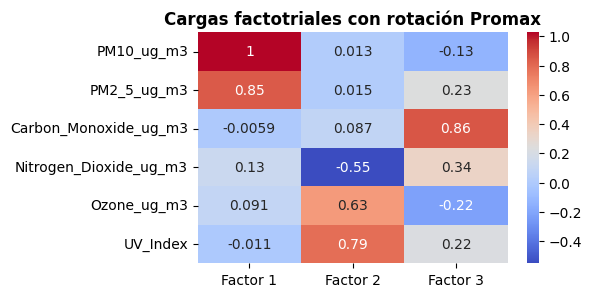

In [ ]:
modelo_promax = FactorAnalyzer(n_factors=3, rotation="promax")

modelo_promax.fit(df_scaled)


loadings_promax=pd.DataFrame(modelo_promax.loadings_,
                              index=df_scaled.columns,
                              columns=["Factor 1","Factor 2", "Factor 3"])

plt.figure(figsize=(5,3))
sns.heatmap(loadings_promax,cmap="coolwarm",annot=True)
plt.title("Cargas factotriales con rotación Promax", fontweight="bold")
plt.show()

La extracción con rotación oblicua permite identificar:
* **Factor 1 (Contaminación por material particulado:):** Caracterizado por la concetración de PM10 y PM2.5.Esta puede provenir de diferentes fuentes como la combustión, la construcción, suelo descubierto, polvo suspendido y aerosoles secundarios formados en la atmósfera.
* **Factor 2 (procesos fotoquimicos):** Caracterizado por el indice de rayos UV y de ozono, y en sentido opuesto por NO2.



> En la cotidianidad, el NO2 se descompone ante la presencia de rayos UV, por lo cual, a medida que aumenta la radiación UV, disminuye la concentración de NO2.
>
>Por otro lado, los rayos UV inciden en la formación del ozono troposferico (O3). Es decir que a medida que aumenta la radiación, aumenta la concentración de ozono.
>
> Por último, la reacción quimica:
>
> O3 + NO -> NO2 + O2
>
> Muestra que el ozono de la atmosfera reacciona con el monoxido de nitrogeno favoreciendo la formacion de dioxido de nitrogeno y oxigeno (O2). Por lo cual una disminución de ozono está asociada a una aumento de NO2.



* **Factor 3 (emisiones de combustión urbana):** Caracterizado por la presencia de CO y en menor medida de NO2. Pueden proceder de  procesos de combustión incompleta, derivados del tráfico vehicular y fuentes de combustión urbana. Su presencia en el factor 3 puede reflejar la presencia de emisiones primarias y sus productos de oxidación atmosférica

Con base en la interpretabilidad de las cargas y la cantidad de cargas cruzadas, la mejor rotación para el entendimiento del fenómeno es el Promax.

## **Paso 7: Comunalidades:**

La comunalidad representa la proporción de la varianza explicada por los factores comunes en una variable.
Se calcula como la suma de los pesos factoriales al cuadradao en cada  una de las filas.

Esta magnitud indica lo siguiente:

* Si tiene un valor alto, la comunalidad es alta y la variable está bien representada.

* Si tiene un valor bajo, la comunalidad es baja y esta mal representada.

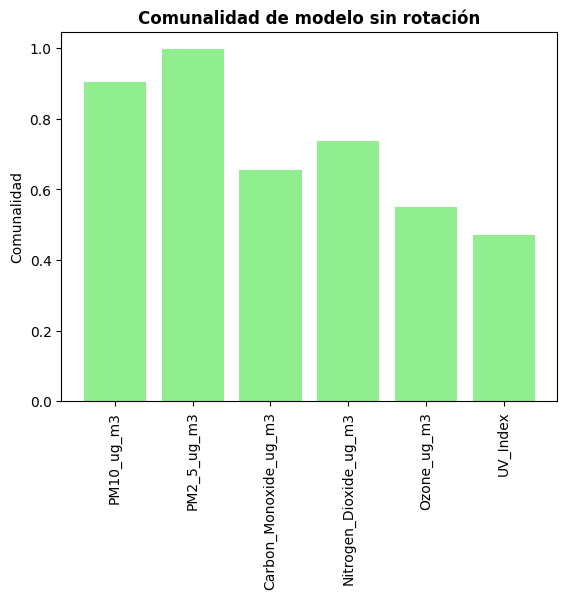

In [ ]:
comm_none=np.sum(loadings_none**2,axis=1)
comm_none=pd.DataFrame({"Variable:":df_scaled.columns,
                        "Comunalidad sin rotación:":comm_none})
plt.bar(comm_none["Variable:"], comm_none["Comunalidad sin rotación:"], color="lightgreen")
plt.title("Comunalidad de modelo sin rotación", fontweight="bold")
plt.ylabel("Comunalidad")
plt.xticks(rotation=90)
plt.show()

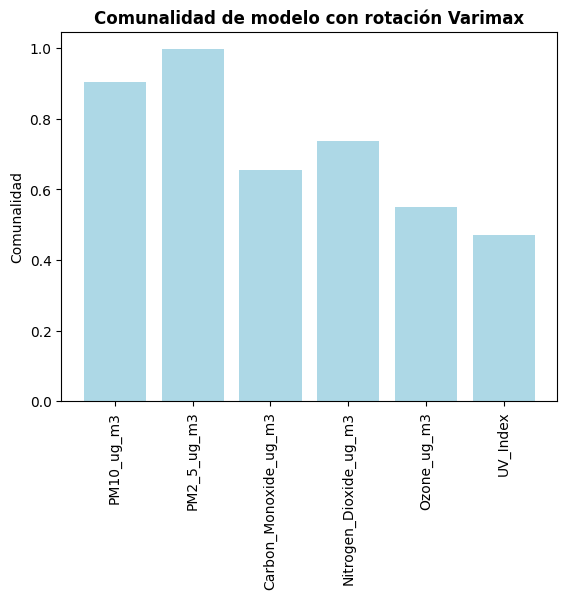

In [ ]:
comm_varimax=np.sum(loadings_varimax**2,axis=1)
comm_varimax=pd.DataFrame({"Variable:":df_scaled.columns,
                        "Comunalidad varimax:":comm_varimax})
plt.bar(comm_varimax["Variable:"],comm_varimax["Comunalidad varimax:"], color="lightblue")
plt.xticks(rotation=90)
plt.title("Comunalidad de modelo con rotación Varimax", fontweight="bold")
plt.ylabel("Comunalidad")
plt.show()

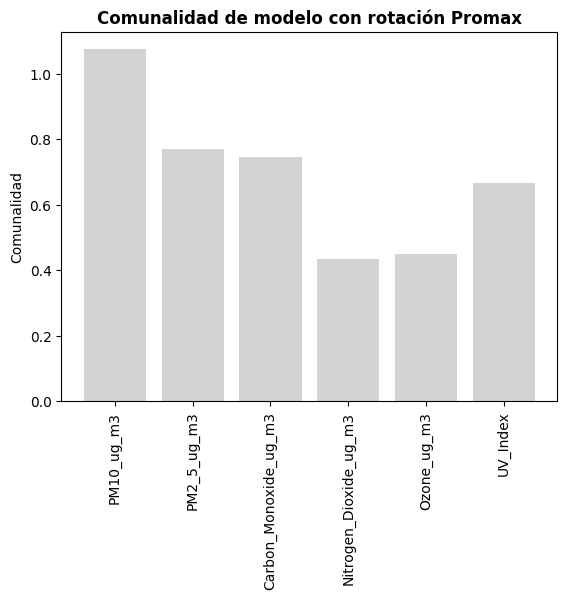

In [ ]:
comm_promax=np.sum(loadings_promax**2,axis=1)
comm_promax=pd.DataFrame({"Variable:":df_scaled.columns,
                        "Comunalidad promax:":comm_promax})
plt.bar(comm_promax["Variable:"],comm_promax["Comunalidad promax:"], color="lightgray")
plt.xticks(rotation=90)
plt.title("Comunalidad de modelo con rotación Promax", fontweight="bold")
plt.ylabel("Comunalidad")
plt.show()

Las comunalidades fueron evaluadas bajo diferentes métodos de rotación factorial. La solución final se seleccionó con base en la coherencia teórica del modelo, la estabilidad de las estimaciones y la interpretabilidad de la estructura factorial.

## **Paso 8: Evaluación Alpha de  cronbach:**


**Interpretación de resultados:**

* Alpha > 0.90 Excelente
* 0.80 - 0.89 Buena
*  0.70 - 0.79 Aceptable
* < 0.60 Baja



 Dado que el NO2 es importante en el factor 2, pero se encuentra en dirección opuesta, podemos analizarlo mediantet el alpha crobetch mientras este en la misma dirección, por esta razón surge la necesidad de invertirlo.


In [ ]:
df_scaled_copy=df_scaled.copy()
df_scaled_copy['NO2_inv'] = -df_scaled_copy['Nitrogen_Dioxide_ug_m3']


In [ ]:
factor1_items = ['PM10_ug_m3', 'PM2_5_ug_m3']
factor2_items = [ 'Ozone_ug_m3', 'UV_Index','NO2_inv']
factor3_items = ['Carbon_Monoxide_ug_m3','Nitrogen_Dioxide_ug_m3']

In [ ]:
alpha_f1, _ = pg.cronbach_alpha(df_scaled_copy[factor1_items])
alpha_f2, _ = pg.cronbach_alpha(df_scaled_copy[factor2_items])
alpha_f3,_ = pg.cronbach_alpha(df_scaled_copy[factor3_items])



In [ ]:
print(alpha_f1)

0.947756023450208


In [ ]:
print(alpha_f2)

0.7309529364359411


In [ ]:
print(alpha_f3)

0.7084475485463693


In [ ]:
alphas = pd.DataFrame({"Alpha Cronbach:":[alpha_f1,alpha_f2,alpha_f3]},
                      index=["Factor 1","Factor 2","Factor 3"])
alphas

,Alpha Cronbach:
Factor 1,0.947756
Factor 2,0.730953
Factor 3,0.708448


## **Conclusiones:**

El análsis factorial permitió caractetrizar los factores comunes en 3 factores latentes:

* Factor 1: Contaminación por material particulado (PM10–PM2.5)

* Factor 2: Procesos fotoquímicos atmosféricos (O₃–UV)

* Factor 3: Emisiones por combustión urbana (CO–NO₂)